In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns

sns.set()

In [2]:

df = pd.read_csv(Path("../") / "results" / "classification_results.csv")
df

,subject,dataset,model,epoch_window,accuracy
0,1,Lee2019_MI,Deep4Net,w_00_30,0.83000
1,1,Lee2019_MI,Deep4Net,w_05_35,0.77000
2,2,Lee2019_MI,Deep4Net,w_00_30,0.79000
3,2,Lee2019_MI,Deep4Net,w_05_35,0.74000
4,3,Lee2019_MI,Deep4Net,w_00_30,0.84000
...,...,...,...,...,...
721,85,Dreyer2023_wo_p,Deep4Net,w_00_40,0.81875
722,86,Dreyer2023_wo_p,Deep4Net,w_05_45,0.69375
723,86,Dreyer2023_wo_p,Deep4Net,w_00_40,0.86875
724,87,Dreyer2023_wo_p,Deep4Net,w_05_45,0.89375


In [3]:
save_base = Path("./figures")
save_base.mkdir(exist_ok=True)

enable_title = False

/tmp/ipykernel_18733/1488165649.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["accuracy"] *= 100


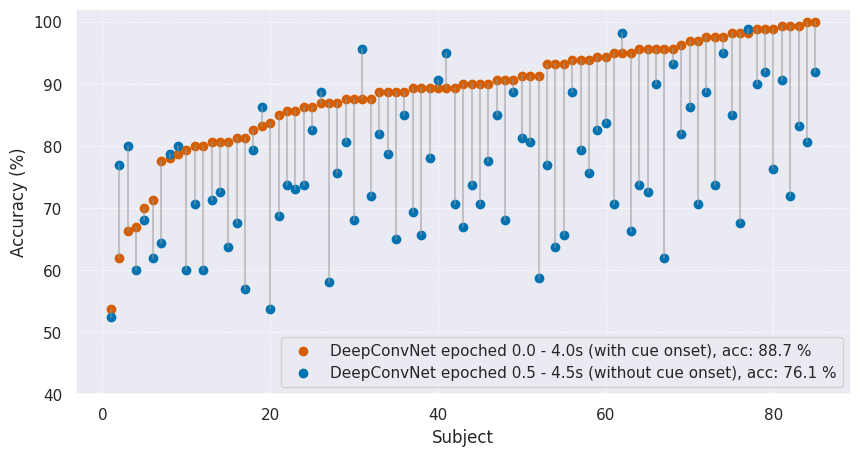

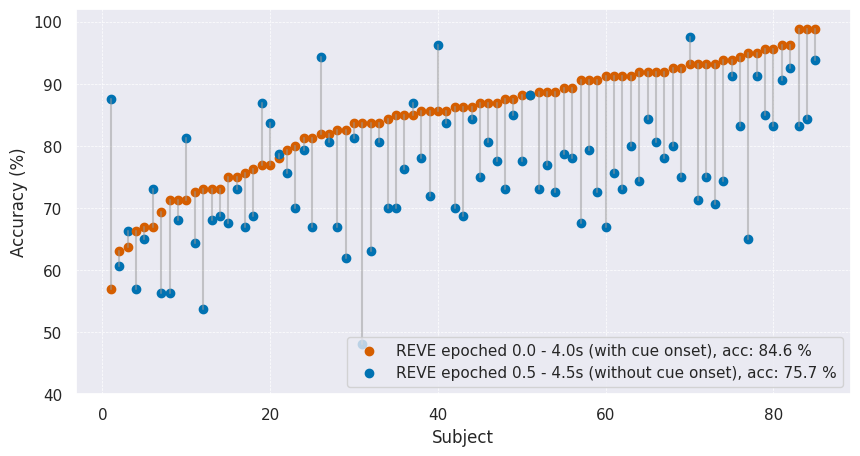

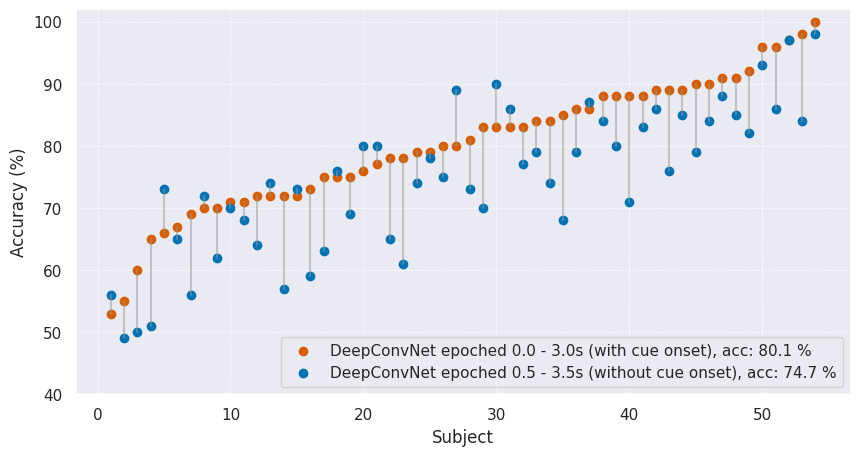

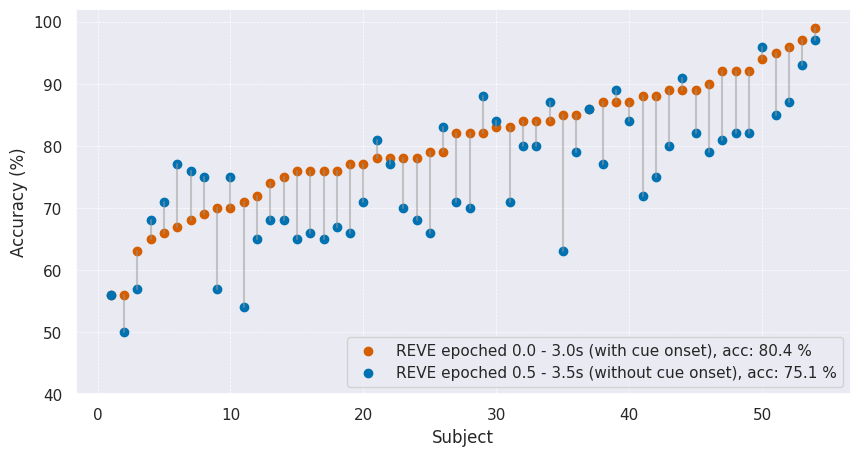

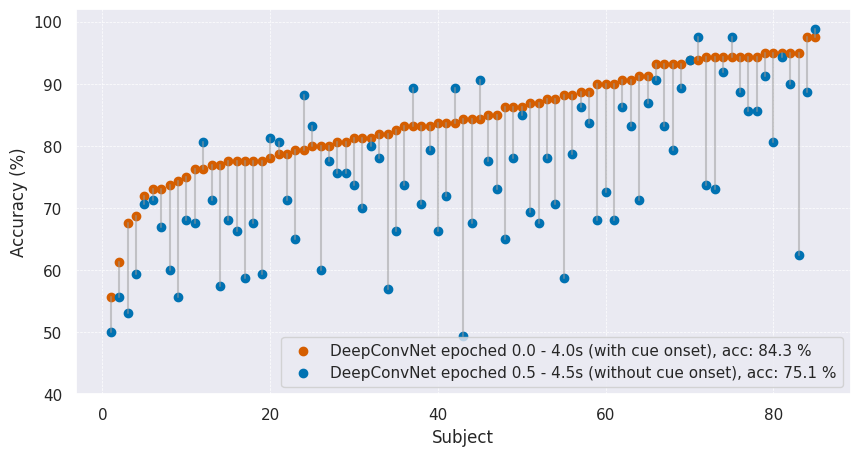

In [7]:
def win_name(window):
    t1 = window.split("_")[1]
    t2 = window.split("_")[2]
    t1 = f"{t1[0]}.{t1[1]}"
    t2 = f"{t2[0]}.{t2[1]}"

    return float(t1), float(t2)


def plot_accuracy(df, dataset, model, windows=["w_00_40", "w_05_45"], colors=["#D55E00", "#0072b2"], ax=None,
                  model_name=None,
                  mode=None):
    if ax is None:
        _, ax = plt.subplots()

    df = df[(df["dataset"] == dataset) & (df["model"] == model)]

    if mode is not None:
        df = df[df["mode"] == mode]

    if "session" in list(df.columns):
        df = df.groupby(["mode", "dataset", "subject", "model", "epoch_window"])["accuracy"].mean().reset_index()

    df["accuracy"] *= 100

    df_window_0 = df[df["epoch_window"] == windows[0]]
    df_window_1 = df[df["epoch_window"] == windows[1]]

    df_window_0 = df_window_0.sort_values("subject")
    df_window_1 = df_window_1.sort_values("subject")

    d = df_window_0["accuracy"].to_numpy() - df_window_1["accuracy"].to_numpy()
    diff = pd.DataFrame(
        {
            "subject": df_window_0["subject"],
            "diff": d
        }
    ).sort_values("diff")

    t0_1, t0_2 = win_name(windows[0])
    t1_1, t1_2 = win_name(windows[1])

    mean_acc_0 = df_window_0["accuracy"].mean()
    mean_acc_1 = df_window_1["accuracy"].mean()

    for idx, subject in enumerate(df_window_0.sort_values("accuracy")["subject"].to_list()):
        a = df_window_0[df_window_0["subject"] == subject]["accuracy"].to_numpy()[0]
        b = df_window_1[df_window_1["subject"] == subject]["accuracy"].to_numpy()[0]

        ax.plot([idx + 1, idx + 1], [a, b], color="#999999", alpha=0.5)

        if idx == 0:
            label_0 = f"{model_name} epoched {t0_1} - {t0_2}s (with cue onset), acc: {mean_acc_0:.1f} %"
            label_1 = f"{model_name} epoched {t1_1} - {t1_2}s (without cue onset), acc: {mean_acc_1:.1f} %"
        else:
            label_0 = None
            label_1 = None

        ax.scatter(idx + 1, a, color=colors[0], label=label_0)
        ax.scatter(idx + 1, b, color=colors[1], label=label_1)

    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    ax.set_ylim([40, 102])
    ax.legend(loc="lower right")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.set_ylabel("Accuracy (%)")
    ax.set_xlabel("Subject")


fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df, dataset="Dreyer2023", model="Deep4Net", windows=["w_00_40", "w_05_45"], ax=ax,
              model_name="DeepConvNet")
if enable_title:
    fig.suptitle("Dreyer2023 (DeepConvNet)")
fig.savefig(save_base / "Dreyer2023_DeepConvNet.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df, dataset="Dreyer2023", model="REVE", windows=["w_00_40", "w_05_45"], ax=ax, model_name="REVE")
if enable_title:
    fig.suptitle("Dreyer2023 (REVE)")
fig.savefig(save_base / "Dreyer2023_REVE.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df, dataset="Lee2019_MI", model="Deep4Net", windows=["w_00_30", "w_05_35"], ax=ax,
              model_name="DeepConvNet")
if enable_title:
    fig.suptitle("Lee2019_MI (DeepConvNet)")
fig.savefig(save_base / "Lee2019_MI_DeepConvNet.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df, dataset="Lee2019_MI", model="REVE", windows=["w_00_30", "w_05_35"], ax=ax, model_name="REVE")
if enable_title:
    fig.suptitle("Lee2019_MI (REVE)")
fig.savefig(save_base / "Lee2019_MI_REVE.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df, dataset="Dreyer2023_wo_p", model="Deep4Net", windows=["w_00_40", "w_05_45"], ax=ax,
              model_name="DeepConvNet")
if enable_title:
    fig.suptitle("Dreyer2023 w/o the P-line (DeepConvNet)")
fig.savefig(save_base / "Dreyer2023_wo_p_DeepConvNet.png", dpi=300)



# CSP + LDA

In [5]:
df_csp = pd.read_csv(Path("../") / "results" / "classification_results_csp_lda.csv")
df_csp


,mode,dataset,subject,session,model,epoch_window,accuracy
0,within_user,Lee2019_MI,1,1,CSP_LDA,w_05_35,0.52000
1,within_user,Lee2019_MI,1,2,CSP_LDA,w_05_35,0.46000
2,within_user,Dreyer2023,1,1,CSP_LDA,w_00_40,0.76875
3,within_user,Dreyer2023,1,1,CSP_LDA,w_05_45,0.83750
4,within_user,Lee2019_MI,1,1,CSP_LDA,w_00_30,0.56000
...,...,...,...,...,...,...,...
767,cross_user,Dreyer2023,86,1,CSP_LDA,w_05_45,0.51250
768,within_user,Dreyer2023,87,1,CSP_LDA,w_05_45,0.84375
769,cross_user,Dreyer2023,87,1,CSP_LDA,w_00_40,0.83125
770,cross_user,Dreyer2023,87,1,CSP_LDA,w_05_45,0.90625


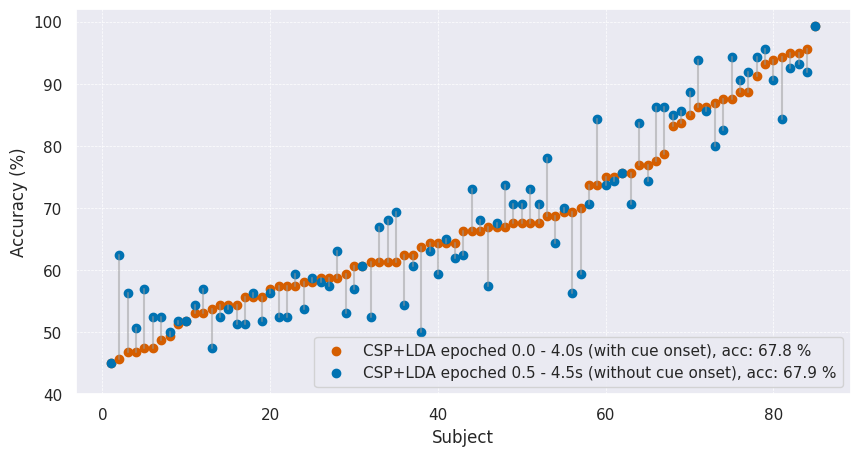

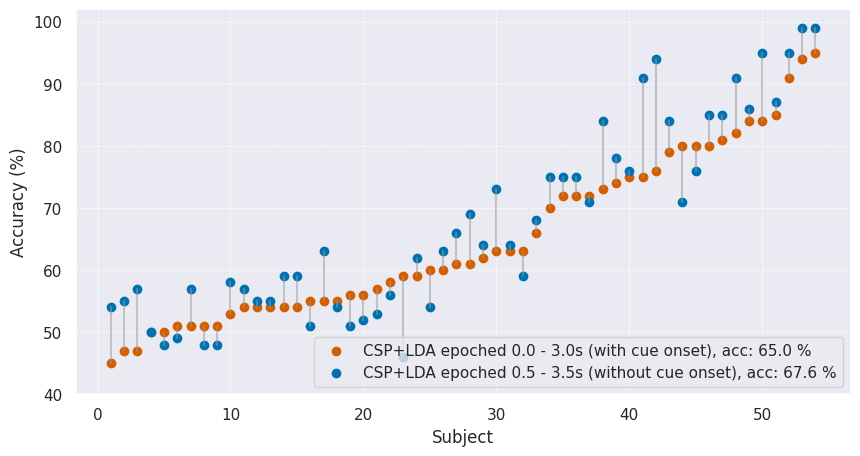

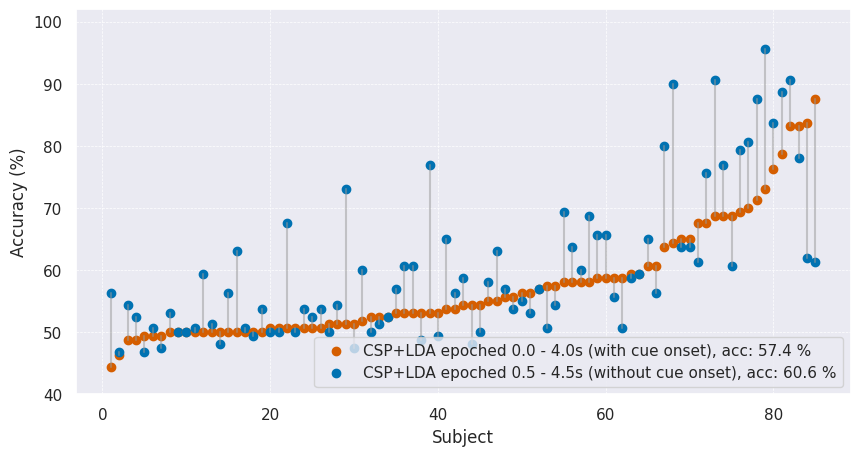

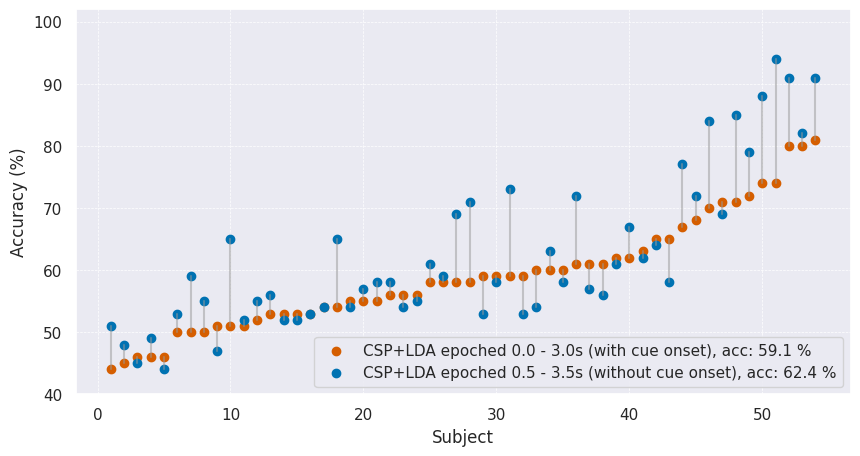

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df_csp, dataset="Dreyer2023", model="CSP_LDA", windows=["w_00_40", "w_05_45"], ax=ax,
              model_name="CSP+LDA", mode="within_user")
if enable_title:
    fig.suptitle("Dreyer2023 (CSP+LDA) - Within-Subject approach")
fig.savefig(save_base / "Dreyer2023_CSP_LDA_within.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df_csp, dataset="Lee2019_MI", model="CSP_LDA", windows=["w_00_30", "w_05_35"], ax=ax,
              model_name="CSP+LDA", mode="within_user")
if enable_title:
    fig.suptitle("Lee2019_MI (CSP+LDA) - Within-Subject approach")
fig.savefig(save_base / "Lee2019_MI_CSP_LDA_within.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df_csp, dataset="Dreyer2023", model="CSP_LDA", windows=["w_00_40", "w_05_45"], ax=ax,
              model_name="CSP+LDA", mode="cross_user")
if enable_title:
    fig.suptitle("Dreyer2023 (CSP+LDA) - Cross-Subject approach")
fig.savefig(save_base / "Dreyer2023_CSP_LDA_cross.png", dpi=300)

fig, ax = plt.subplots(figsize=(10, 5))
plot_accuracy(df_csp, dataset="Lee2019_MI", model="CSP_LDA", windows=["w_00_30", "w_05_35"], ax=ax,
              model_name="CSP+LDA", mode="cross_user")
if enable_title:
    fig.suptitle("Lee2019_MI (CSP+LDA) - Cross-Subject approach")
fig.savefig(save_base / "Lee2019_MI_CSP_LDA_cross.png", dpi=300)
